In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
from zipfile import ZipFile
with ZipFile('archive (10).zip',mode = 'r') as project_data:
    with project_data.open('hospital_deterioration_hourly_panel.csv',mode = 'r') as deterioration_hourly_panel:
        deterioration_hourly_panel = pd.read_csv(deterioration_hourly_panel)
    with project_data.open('patients.csv',mode = 'r') as patients:
        patients = pd.read_csv(patients)

In [10]:
num_positives = deterioration_hourly_panel.groupby('patient_id')['deterioration_next_12h'].agg(['sum','size'])
count_df = num_positives.loc[num_positives['sum']>0]
print("A look at the number of 12 markers: 'deterioration_next_12h'")
print(f'Of {num_positives.shape[0]} patients, {count_df.shape[0]} have presenxe of 12-hour markers')
print(f'There are a totla of {count_df['sum'].sum()} observations == True for 12-hour markers')
print('Here is a sample')
display(count_df.rename(columns={'size':'hours'}))

A look at the number of 12 markers: 'deterioration_next_12h'
Of 10000 patients, 1938 have presenxe of 12-hour markers
There are a totla of 22589 observations == True for 12-hour markers
Here is a sample


,sum,hours
patient_id,,
2,12,33
13,12,68
14,12,22
22,12,57
24,12,40
...,...,...
9968,12,26
9971,11,46
9973,12,53


patient stay lenghts


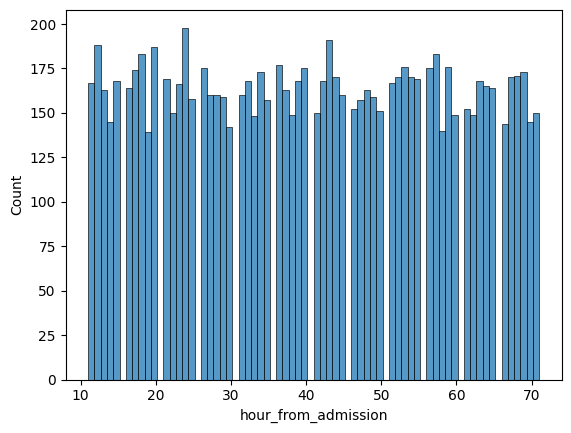

In [ ]:
patients_per_hour = deterioration_hourly_panel.groupby('patient_id',as_index=True)['hour_from_admission'].max()
print('patient stay lenghts')
sns.histplot(patients_per_hour,bins=72)
plt.show()


patients with instance of deterioration in next 12 hours == True


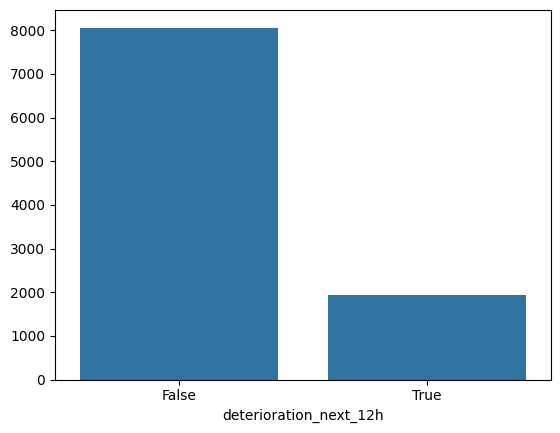

In [ ]:

patients_w_and_wo_12_hour = deterioration_hourly_panel.groupby('patient_id',as_index=True)['deterioration_next_12h'].sum()
patients_w_and_wo_12_hour = (patients_w_and_wo_12_hour>=1)

print('patients with instance of deterioration in next 12 hours == True')
counts = patients_w_and_wo_12_hour.value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.show()

a look at the hour of first deterioration


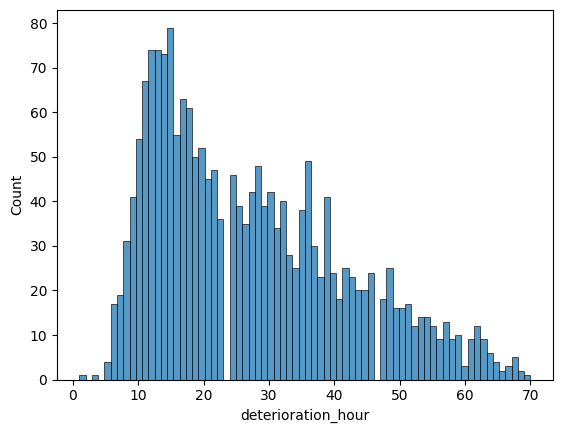

In [ ]:
print('a look at the hour of first deterioration')
first_deterioration = patients.loc[patients['deterioration_hour']!=-1]['deterioration_hour']
sns.histplot(first_deterioration,bins=72)
plt.show()

a look at the first hour when deterioration within 12 became true
by patient


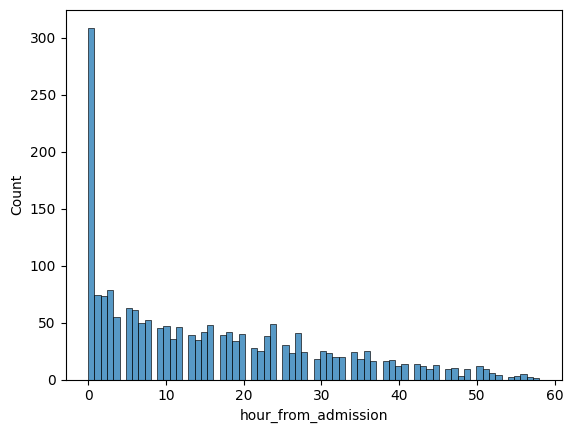

In [ ]:
print('a look at the first hour when deterioration within 12 became true')
print('by patient')
first_hour_w_next_12_true = deterioration_hourly_panel.loc[deterioration_hourly_panel['deterioration_next_12h']==1]
first_hour_by_patient = first_hour_w_next_12_true.groupby('patient_id',as_index=True)['hour_from_admission'].min()
sns.histplot(first_hour_by_patient,bins=72)
plt.show()